# Labeling images, measuring inter-annotator agreement, revising the guide

In this demo, the group will:

1. write a first labeling guide to classify landscape photos;
2. label 10 photos following that guide;
3. measure the agreement between annotators;
4. revise the guide from the photos that split the group;
5. label the photos again, then compare both measures.

This is the loop for writing a labeling guide: a version, labeling, spotting the ambiguous points, a new version.

The cells hold example annotations, so that the notebook runs as is.

## Fetching the Data

In [1]:
import pathlib

!rm -rf sample_data

if not pathlib.Path("landscape").is_dir():
  !wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s landscape

!mkdir -p to-annotate

ids = [10034, 10159, 10244, 1060, 1072, 11, 11105, 1223, 12326, 12971]
for i, id in enumerate(ids):
  !cp landscape/seg_pred/no_supervision/{id}.jpg to-annotate/{i}.jpg

The next cell defines the demo's tools (displaying the images, reading the annotations, computing the agreement). Run it, there's no need to read its code.

In [2]:
#@title Demo tools (run the cell, no need to read its code)
import math
import pathlib
import random
import re

import matplotlib.pyplot as plt
import numpy
import statsmodels.stats.inter_rater
from PIL import Image

classes = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
# French class names are accepted too
aliases = {
  "bâtiments": "buildings", "bâtiment": "buildings", "batiments": "buildings", "batiment": "buildings",
  "forêt": "forest", "foret": "forest",
  "montagne": "mountain",
  "mer": "sea",
  "rue": "street", "route": "street",
}
images = sorted(pathlib.Path("to-annotate").glob("*.jpg"), key=lambda path: int(path.stem))


def show_examples(per_class=6):
  """Show random images of each class from the training set."""
  random.seed(0)
  fig, axes = plt.subplots(len(classes), per_class, figsize=(2 * per_class, 2.2 * len(classes)))
  for row, name in zip(axes, classes):
    paths = random.sample(sorted(pathlib.Path("landscape/seg_train", name).glob("*.jpg")), per_class)
    for ax, path in zip(row, paths):
      ax.imshow(Image.open(path))
      ax.axis("off")
    row[0].set_title(name, loc="left", fontweight="bold")
  plt.tight_layout()
  plt.show()


def show_images(order=None, titles=None, colors=None):
  """Show the images to label, in the given order, with the given titles and colors."""
  order = list(range(len(images))) if order is None else order
  rows = math.ceil(len(order) / 5)
  fig, axes = plt.subplots(rows, 5, figsize=(15, 3.6 * rows), squeeze=False)
  for ax in axes.flat:
    ax.axis("off")
  for ax, i in zip(axes.flat, order):
    ax.imshow(Image.open(images[i]))
    ax.set_title(f"Image {i}" if titles is None else titles[i], color="black" if colors is None else colors[i])
  plt.tight_layout()
  plt.show()


def read_annotations(text):
  """Read annotations pasted from a spreadsheet: one line per annotator, their name then one class per image."""
  annotations = {}
  for line in text.strip().splitlines():
    fields = line.split("\t") if "\t" in line else re.split(r"[\s,;]+", line)
    fields = [field.strip() for field in fields if field.strip()]
    if not fields:
      continue
    name = fields[0]
    labels = [aliases.get(label.lower(), label.lower()) for label in fields[1:]]
    unknown = [label for label in labels if label not in classes]
    if unknown:
      raise ValueError(f"{name}: unknown class(es) {unknown}. Possible classes: {classes}")
    if len(labels) != len(images):
      raise ValueError(f"{name}: {len(labels)} class(es) instead of {len(images)}, one per image")
    annotations[name] = labels
  if len(annotations) < 2:
    raise ValueError("Measuring agreement takes at least two annotators")
  print(f"{len(annotations)} annotators: {', '.join(annotations)}")
  return annotations


def votes(annotations):
  """Count, for each image, how many annotators chose each class."""
  table = numpy.zeros((len(images), len(classes)), dtype=int)
  for labels in annotations.values():
    for i, label in enumerate(labels):
      table[i, classes.index(label)] += 1
  return table


def image_agreement(annotations):
  """Share of annotator pairs who chose the same class, for each image."""
  table = votes(annotations)
  n = len(annotations)
  return ((table**2).sum(axis=1) - n) / (n * (n - 1))


def kappa(annotations):
  """Fleiss' kappa: the agreement between annotators, corrected for chance agreement."""
  return statsmodels.stats.inter_rater.fleiss_kappa(votes(annotations))


def describe(value):
  """Qualify a kappa on the indicative scale of Landis and Koch (1977)."""
  if value < 0:
    return "worse than chance"
  for threshold, word in [(0.2, "slight agreement"), (0.4, "fair agreement"), (0.6, "moderate agreement"), (0.8, "substantial agreement")]:
    if value <= threshold:
      return word
  return "almost perfect agreement"


def report(annotations):
  """Show the kappa, then the images from the least to the most consensual."""
  value = kappa(annotations)
  print(f"Fleiss' kappa: {value:.2f} ({describe(value)}), {len(annotations)} annotators, {len(images)} images")
  table = votes(annotations)
  agreement = image_agreement(annotations)
  order = sorted(range(len(images)), key=lambda i: agreement[i])
  titles = {}
  for i in order:
    counts = sorted(((table[i, j], name) for j, name in enumerate(classes) if table[i, j]), reverse=True)
    titles[i] = f"Image {i} · agreement {agreement[i]:.0%}\n" + ", ".join(f"{name} {count}" for count, name in counts)
  colors = {i: "black" if agreement[i] == 1 else "tab:red" for i in order}
  disputed = [i for i in order if agreement[i] < 1]
  print(f"Images without unanimity (in red): {', '.join(map(str, disputed)) or 'none'}")
  show_images(order, titles, colors)
  return value


def compare(before, after):
  """Compare the kappas and the agreement on each image between two labeling rounds."""
  kappa_before, kappa_after = kappa(before), kappa(after)
  print(f"Fleiss' kappa, round 1: {kappa_before:.2f} ({describe(kappa_before)})")
  print(f"Fleiss' kappa, round 2: {kappa_after:.2f} ({describe(kappa_after)})")
  x = numpy.arange(len(images))
  fig, ax = plt.subplots(figsize=(10, 3.5))
  ax.bar(x - 0.2, image_agreement(before), width=0.4, label="Round 1 (guide v1)")
  ax.bar(x + 0.2, image_agreement(after), width=0.4, label="Round 2 (guide v2)")
  ax.set_xticks(x, [f"Image {i}" for i in x])
  ax.set_ylim(0, 1.05)
  ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
  ax.set_ylabel("Annotator pairs in agreement")
  ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
  plt.tight_layout()
  plt.show()

## The Data

The dataset sorts landscape photos into 6 classes: `buildings`, `forest`, `glacier`, `mountain`, `sea` and `street`. Here are a few random examples of each class from the training set:

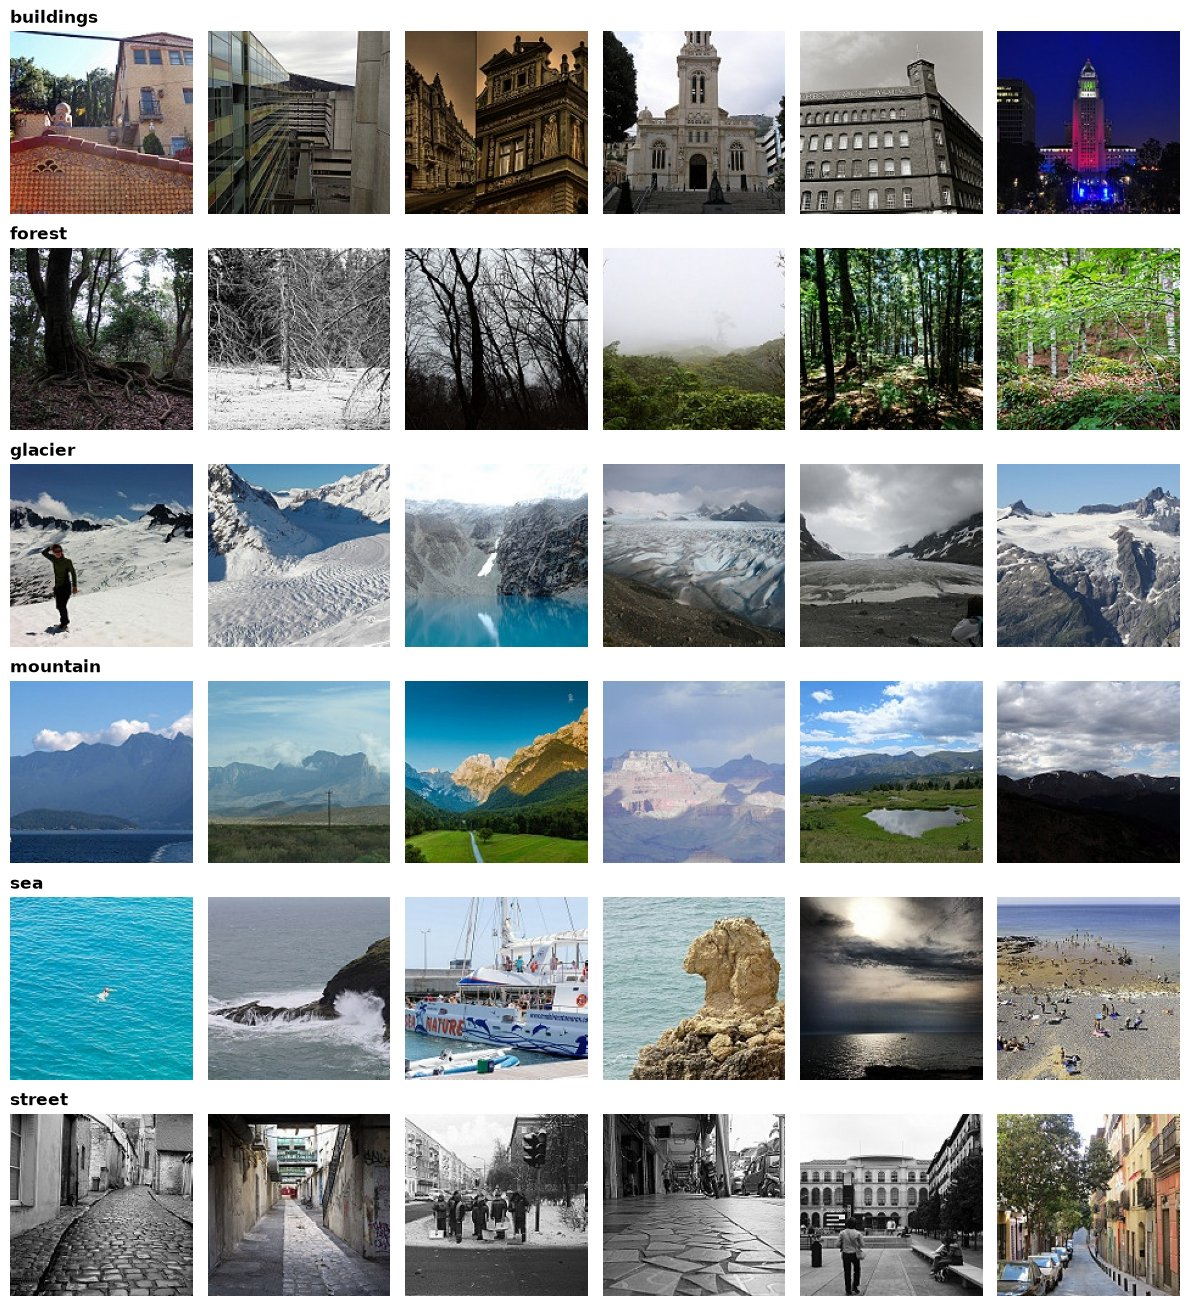

In [3]:
show_examples()

And the 10 photos the group will label, numbered 0 to 9:

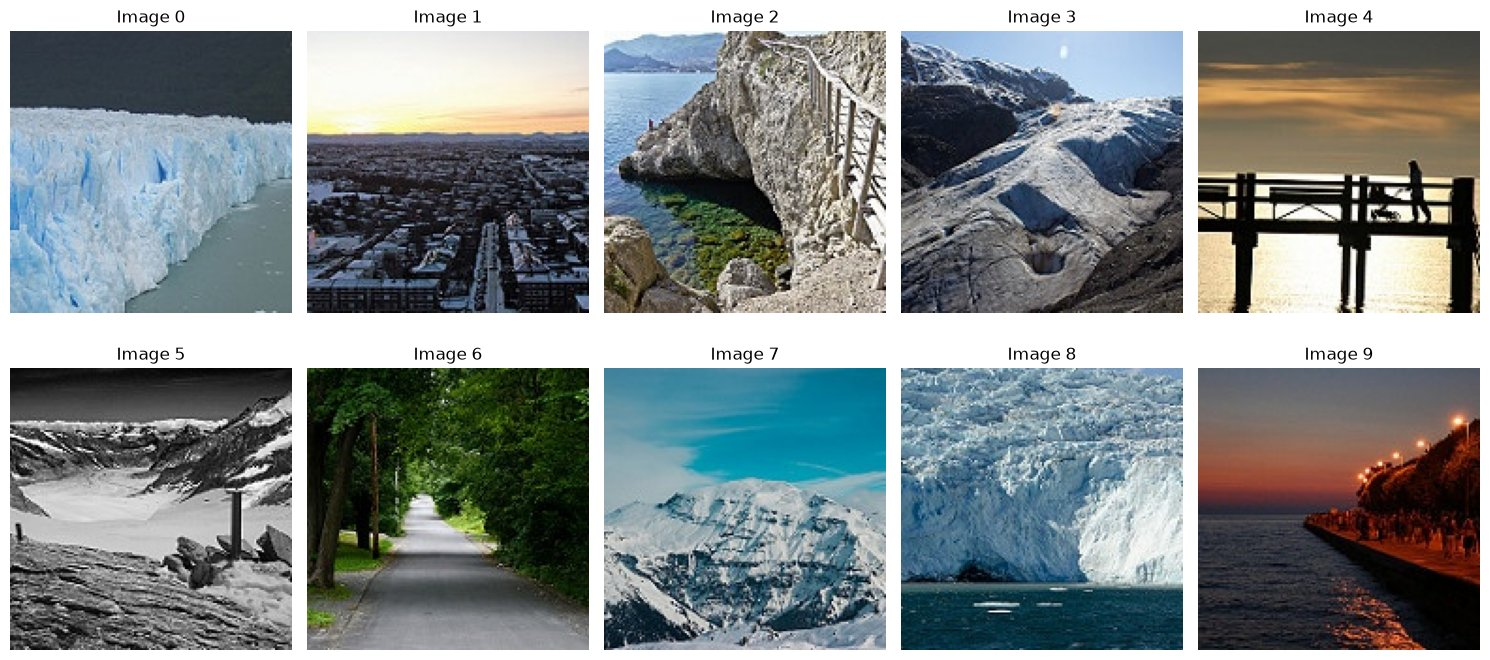

In [4]:
show_images()

## Labeling Guide, Version 1

From the examples above, the group writes a first version of the guide: one rule per class, which lets someone who didn't attend the discussion choose a photo's class.

**Guide, version 1** (example)

- `buildings`: buildings
- `forest`: trees
- `glacier`: ice or snow
- `mountain`: mountains
- `sea`: the sea
- `street`: a street or a road

## Labeling, Round 1

Each participant labels the 10 photos following the guide, without discussing them with the others. On the shared medium (spreadsheet or form), they give their name, then one class per photo, in order from 0 to 9. French class names (`bâtiments`, `forêt`, `montagne`, `mer`, `rue`) are accepted too.

In [5]:
# One line per participant: their name (one word) then the 10 classes, separated by
# tabs (copied from a spreadsheet), commas or spaces
annotations_v1 = read_annotations("""
Alice  glacier  buildings  sea       glacier   sea       glacier   forest  glacier   glacier  sea
Bruno  glacier  street     mountain  mountain  sea       mountain  street  mountain  glacier  street
Chloé  glacier  buildings  mountain  glacier   street    glacier   forest  glacier   glacier  sea
David  glacier  buildings  sea       mountain  buildings mountain  street  mountain  glacier  sea
Emma   glacier  street     sea       glacier   sea       glacier   forest  glacier   glacier  street
""")

5 annotators: Alice, Bruno, Chloé, David, Emma


## Measuring Inter-Annotator Agreement

For each photo, we look at the share of annotator pairs who chose the same class. **Fleiss' kappa** sums up this agreement over all the photos, comparing it with the agreement we'd get if everyone picked classes at random (following how often each class appears in the answers):

- 1: perfect agreement;
- 0: no better than chance;
- below 0: less agreement than chance.

It extends Cohen's kappa, which compares two annotators, to any number of annotators. Its value depends on the number of classes and on the photos chosen: it's mostly useful to compare two measures taken in the same conditions, as here before and after revising the guide. The label shown follows the scale of Landis and Koch (1977), which is only indicative.

The figure shows the photos from the least to the most consensual, with the votes for each.

Fleiss' kappa: 0.36 (fair agreement), 5 annotators, 10 images
Images without unanimity (in red): 4, 1, 2, 3, 5, 6, 7, 9


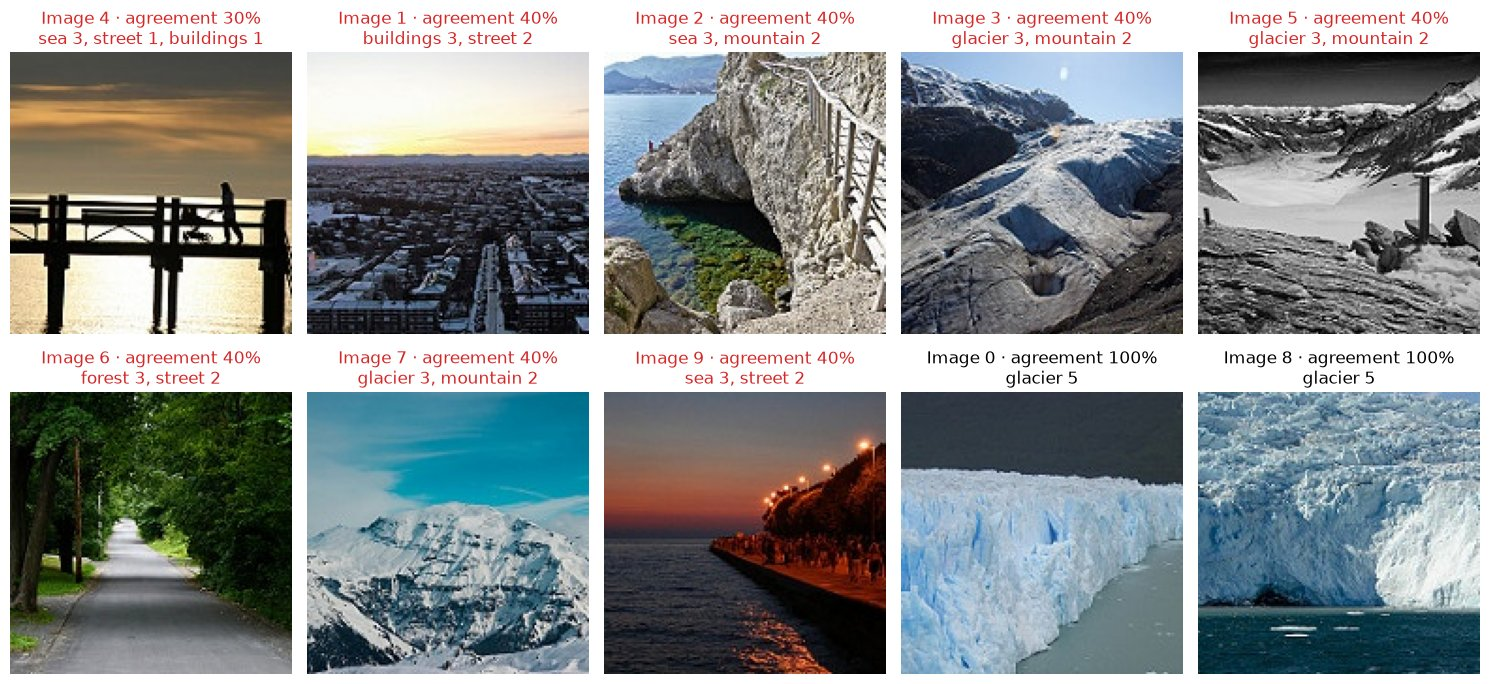

In [6]:
kappa_v1 = report(annotations_v1)

## Revising the Guide

The group goes back over the photos in red, starting with those that split it the most. For each one:

- Which rule of the guide was ambiguous, or missing?
- Which rule would have let everyone choose the same class?

From this it writes version 2 of the guide: definitions that settle the borderline cases explicitly, and a priority order when two classes apply to the same photo.

With the example annotations, the disagreements are about ice and snow (glacier or mountain?), water seen next to something else (a pier, a cliff, a promenade: sea?) and roads (street, buildings or forest?).

**Guide, version 2** (example)

Apply the first rule that matches the photo:

1. `glacier`: a mass of ice (bluish, cracked, as a tongue or a front) is clearly visible. Snow on peaks isn't enough.
2. `sea`: water (sea or lake) covers at least a third of the photo, even with a pier, cliffs or a promenade.
3. `mountain`: the relief (peaks, slopes, cliffs) dominates, snowy or not.
4. `street`: seen from the ground, a street, a road or a path leads into the photo, even between trees or buildings.
5. `buildings`: buildings dominate, including a city seen from above.
6. `forest`: trees dominate, and no way leads into the photo.

## Labeling, Round 2

Each participant labels the 10 photos again, with the revised guide and still without discussing them.

In [7]:
annotations_v2 = read_annotations("""
Alice  glacier  buildings  sea       glacier   sea  glacier   street  mountain  glacier  sea
Bruno  glacier  buildings  sea       glacier   sea  mountain  street  mountain  glacier  sea
Chloé  glacier  buildings  sea       glacier   sea  glacier   street  mountain  glacier  sea
David  glacier  buildings  mountain  glacier   sea  glacier   street  mountain  glacier  sea
Emma   glacier  buildings  sea       glacier   sea  glacier   street  mountain  glacier  street
""")

5 annotators: Alice, Bruno, Chloé, David, Emma


Fleiss' kappa: 0.84 (almost perfect agreement), 5 annotators, 10 images
Images without unanimity (in red): 2, 5, 9


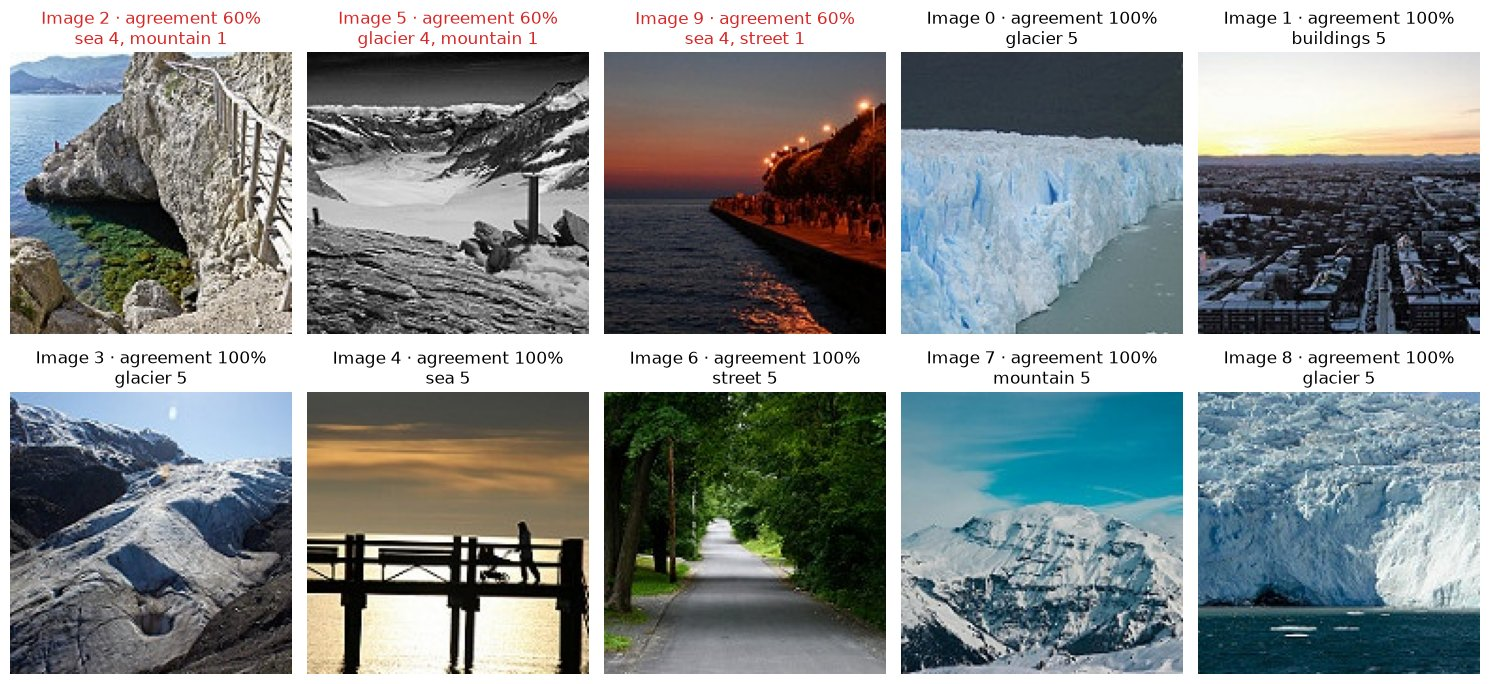

In [8]:
kappa_v2 = report(annotations_v2)

## Comparing Both Rounds

Fleiss' kappa, round 1: 0.36 (fair agreement)
Fleiss' kappa, round 2: 0.84 (almost perfect agreement)


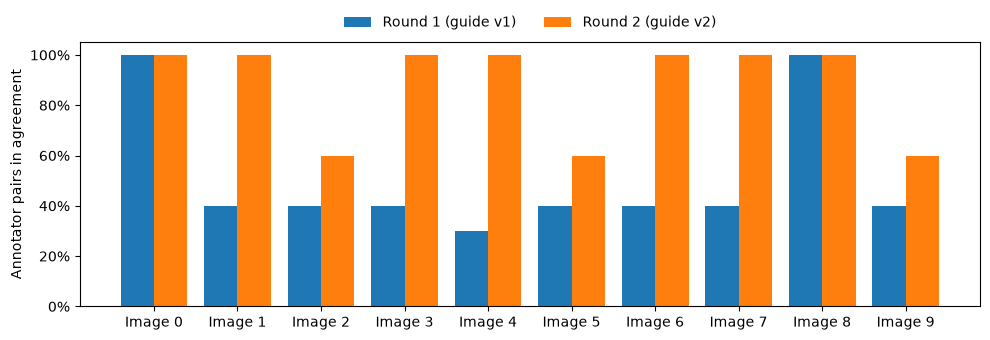

In [9]:
compare(annotations_v1, annotations_v2)

If the revised guide removed the ambiguities, kappa goes up. Two caveats before concluding:

- The participants labeled the same photos twice, after discussing them: part of the gain comes from the discussion itself. In a real project, you check the new guide on photos nobody has seen yet.
- With 10 photos and a few annotators, the measure is very uncertain: a single vote changes kappa markedly.

A photo on which the disagreement persists may be truly ambiguous (it belongs to two classes at once): that's information about the problem, not only about the guide. You can then have an expert settle it, accept several labels, or rethink the class definitions.

## Impact on Human Level Performance

Human Level Performance (*HLP*) is widely used in Machine Learning. What's the impact of bad labeling on HLP? Is a learning algorithm affected by bad labels in the same way?

Leads for the discussion:

- HLP is measured by comparing a human's labels with a reference (or with the other annotators'). With an ambiguous guide, competent annotators contradict each other: the measured HLP drops, but it then reflects inconsistent labels more than how hard the task really is. So it is a poor estimate of the Bayes error.
- A model can then seem to "beat human level" just because it reproduces the majority label better. That's no real progress: clarifying the guide raises HLP and shows the margin left.
- A learning algorithm isn't affected by every error in the same way:
  - few, random errors partly cancel out over many examples, but they call for more data and lower the reachable performance;
  - systematic errors (for instance, always calling a snowy mountain `glacier`) are learned as they are: the model faithfully reproduces the annotators' implicit rule;
  - noisy labels in the test set make the evaluation itself unreliable.
- Making labeling more consistent (the guide, double labeling of ambiguous cases) often pays off more than changing the model.

## Takeaways

- A labeling guide is written iteratively: a version, labeling, spotting the disagreements, a new version.
- Fleiss' kappa measures the agreement between several annotators, corrected for chance (1: perfect, 0: chance). It is mostly useful to compare two measures.
- Disagreements show where the guide is ambiguous, or where the classes themselves overlap.
- Label quality caps the model's quality and how reliable its evaluation is. Measuring it is cheap: a few annotators on a sample are enough.